<a href="https://www.kaggle.com/code/lalit7881/gta-v-worldwide-sales-player-analytics-eda-100?scriptVersionId=332704006" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
# Importing necessary libraries and setting up the environment
import warnings
warnings.filterwarnings('ignore')
import seaborn as sns
import matplotlib
matplotlib.use('Agg')  # Setting backend before importing pyplot
import matplotlib.pyplot as plt

plt.switch_backend('Agg')  # Ensuring backend is switched if only plt is used

from pathlib import Path
import os

# Enabling inline plotting for Jupyter Notebook
%matplotlib inline

# Setting a seaborn theme for better aesthetics
sns.set_theme(style='whitegrid')
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/velvetcrystal/gta-v-worldwide-sales-and-player-analytics/gta_v_worldwide_sales_player_analytics_2013_2026.csv


## Loading dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/velvetcrystal/gta-v-worldwide-sales-and-player-analytics/gta_v_worldwide_sales_player_analytics_2013_2026.csv")

In [3]:
df.head()

,transaction_id,year,month,quarter,country,iso3_code,region,platform,game_edition,sales_channel,...,gaming_market_size,population_millions,gdp_per_capita_usd,release_phase,weekend_sales_percentage,weekday_sales_percentage,season,special_event,top_game_category,platform_generation
0,GTA5-100039,2013,9,3,Algeria,DZA,Africa,PS3,Premium Edition,Physical,...,4.82,38.28,5621.76,Launch,41.4,58.6,Autumn,Xbox Sale,Action-Adventure,Gen7
1,GTA5-100005,2013,9,3,Argentina,ARG,South America,PS3,Standard Edition,Physical,...,23.48,42.31,14452.74,Launch,40.8,59.2,Autumn,Xbox Sale,Action-Adventure,Gen7
2,GTA5-100093,2013,9,3,Argentina,ARG,South America,Xbox 360,Premium Edition,Physical,...,23.96,42.31,14748.61,Launch,51.6,48.4,Autumn,Xbox Sale,Action-Adventure,Gen7
3,GTA5-100072,2013,9,3,Armenia,ARM,Asia,PS3,Standard Edition,Physical,...,0.14,2.92,3879.16,Launch,42.3,57.7,Autumn,Xbox Sale,Action-Adventure,Gen7
4,GTA5-100034,2013,9,3,Australia,AUS,Oceania,PS3,Legacy Edition,Physical,...,231.44,23.17,69365.83,Launch,43.4,56.6,Autumn,Xbox Sale,Action-Adventure,Gen7


In [4]:
df.tail()

,transaction_id,year,month,quarter,country,iso3_code,region,platform,game_edition,sales_channel,...,gaming_market_size,population_millions,gdp_per_capita_usd,release_phase,weekend_sales_percentage,weekday_sales_percentage,season,special_event,top_game_category,platform_generation
14775,GTA5-114683,2026,6,2,United States,USA,North America,PC,Premium Edition,Digital,...,7671.76,365.96,65510.55,Legacy,48.8,51.2,Summer,Steam Summer Sale,Action-Adventure,PC
14776,GTA5-114771,2026,6,2,United States,USA,North America,Xbox Series X|S,Standard Edition,Digital,...,7555.14,365.96,64514.73,Growth,41.5,58.5,Summer,Steam Summer Sale,Action-Adventure,Gen9
14777,GTA5-114691,2026,6,2,Uruguay,URY,South America,PC,Standard Edition,Digital,...,0.79,3.94,20815.83,Legacy,59.9,40.1,Summer,Steam Summer Sale,Action-Adventure,PC
14778,GTA5-114779,2026,6,2,Uruguay,URY,South America,Xbox Series X|S,Standard Edition,Digital,...,0.77,3.94,20269.18,Growth,47.7,52.3,Summer,Steam Summer Sale,Action-Adventure,Gen9
14779,GTA5-114713,2026,6,2,Vietnam,VNM,Asia,Xbox Series X|S,Standard Edition,Digital,...,24.48,104.23,4317.13,Growth,45.6,54.4,Summer,Steam Summer Sale,Action-Adventure,Gen9


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14780 entries, 0 to 14779
Data columns (total 47 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   transaction_id                   14780 non-null  object 
 1   year                             14780 non-null  int64  
 2   month                            14780 non-null  int64  
 3   quarter                          14780 non-null  int64  
 4   country                          14780 non-null  object 
 5   iso3_code                        14780 non-null  object 
 6   region                           14780 non-null  object 
 7   platform                         14780 non-null  object 
 8   game_edition                     14780 non-null  object 
 9   sales_channel                    14780 non-null  object 
 10  retailer                         14780 non-null  object 
 11  units_sold                       14780 non-null  int64  
 12  gross_revenue_usd 

In [6]:
df.describe()

,year,month,quarter,units_sold,gross_revenue_usd,average_selling_price_usd,discount_percentage,digital_sales_percentage,physical_sales_percentage,new_customers,...,customer_rating,review_count,refund_rate_percentage,exchange_rate_to_usd,internet_penetration_percentage,gaming_market_size,population_millions,gdp_per_capita_usd,weekend_sales_percentage,weekday_sales_percentage
count,14780.000000,14780.000000,14780.000000,14780.000000,14780.000000,14780.000000,14780.000000,14780.000000,14780.000000,14780.000000,...,14780.000000,14780.000000,14780.000000,14780.000000,14780.000000,14780.000000,14780.000000,14780.000000,14780.000000,14780.000000
mean,2019.580920,6.525440,2.500406,850.437483,11571.717520,15.106273,36.843965,61.494729,38.505271,352.793234,...,4.550257,15.848241,3.489408,1582.759206,96.711482,230.757881,77.162503,25814.493173,46.087375,53.912625
std,3.724658,3.480096,1.122421,993.338857,13668.030082,6.879634,17.374816,15.419953,15.419953,423.222350,...,0.139301,20.413230,1.478754,9500.887243,5.542113,952.079706,208.491117,24690.139324,4.998563,4.998563
min,2013.000000,1.000000,1.000000,23.000000,176.000000,3.000000,0.000000,27.600000,1.000000,9.000000,...,4.200000,3.000000,0.100000,0.301500,37.000000,0.030000,0.330000,606.780000,30.000000,35.300000
25%,2016.000000,3.000000,1.000000,272.000000,3761.280000,9.760000,25.600000,48.500000,27.600000,111.000000,...,4.457500,4.000000,2.460000,0.912975,98.000000,1.740000,6.320000,6710.667500,42.800000,50.600000
50%,2020.000000,6.000000,2.000000,522.000000,7262.900000,13.525000,40.900000,61.900000,38.100000,216.000000,...,4.550000,9.000000,3.480000,5.073300,98.000000,12.465000,21.470000,16690.350000,46.100000,53.900000
75%,2023.000000,10.000000,4.000000,1029.000000,13845.237500,18.710000,49.500000,72.400000,51.500000,421.000000,...,4.640000,19.000000,4.490000,109.060850,98.000000,52.417500,60.342500,43135.320000,49.400000,57.200000
max,2026.000000,12.000000,4.000000,11130.000000,167483.250000,39.990000,80.000000,99.000000,72.400000,5782.000000,...,5.000000,271.000000,9.360000,91627.528800,98.000000,7729.210000,1605.120000,120894.830000,64.700000,70.000000


In [7]:
df.isnull()

,transaction_id,year,month,quarter,country,iso3_code,region,platform,game_edition,sales_channel,...,gaming_market_size,population_millions,gdp_per_capita_usd,release_phase,weekend_sales_percentage,weekday_sales_percentage,season,special_event,top_game_category,platform_generation
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14775,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
14776,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
14777,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
14778,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [8]:
df.isnull().sum()

transaction_id                        0
year                                  0
month                                 0
quarter                               0
country                               0
iso3_code                             0
region                                0
platform                              0
game_edition                          0
sales_channel                         0
retailer                              0
units_sold                            0
gross_revenue_usd                     0
average_selling_price_usd             0
discount_percentage                   0
digital_sales_percentage              0
physical_sales_percentage             0
new_customers                         0
returning_customers                   0
estimated_active_players              0
peak_concurrent_players               0
online_players                        0
story_mode_players                    0
gta_online_players                    0
dlc_revenue_usd                       0


In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.dtypes

transaction_id                      object
year                                 int64
month                                int64
quarter                              int64
country                             object
iso3_code                           object
region                              object
platform                            object
game_edition                        object
sales_channel                       object
retailer                            object
units_sold                           int64
gross_revenue_usd                  float64
average_selling_price_usd          float64
discount_percentage                float64
digital_sales_percentage           float64
physical_sales_percentage          float64
new_customers                        int64
returning_customers                  int64
estimated_active_players             int64
peak_concurrent_players              int64
online_players                       int64
story_mode_players                   int64
gta_online_

In [11]:
df.shape

(14780, 47)

In [12]:
df.columns

Index(['transaction_id', 'year', 'month', 'quarter', 'country', 'iso3_code',
       'region', 'platform', 'game_edition', 'sales_channel', 'retailer',
       'units_sold', 'gross_revenue_usd', 'average_selling_price_usd',
       'discount_percentage', 'digital_sales_percentage',
       'physical_sales_percentage', 'new_customers', 'returning_customers',
       'estimated_active_players', 'peak_concurrent_players', 'online_players',
       'story_mode_players', 'gta_online_players', 'dlc_revenue_usd',
       'shark_card_revenue_usd', 'average_playtime_hours',
       'average_session_length_minutes', 'holiday_season', 'major_sale_event',
       'marketing_campaign', 'customer_rating', 'review_count',
       'refund_rate_percentage', 'currency', 'exchange_rate_to_usd',
       'internet_penetration_percentage', 'gaming_market_size',
       'population_millions', 'gdp_per_capita_usd', 'release_phase',
       'weekend_sales_percentage', 'weekday_sales_percentage', 'season',
       'special_e

In [13]:
df.nunique()

transaction_id                     14780
year                                  14
month                                 12
quarter                                4
country                               88
iso3_code                             88
region                                 6
platform                               7
game_edition                           4
sales_channel                          2
retailer                              11
units_sold                          2886
gross_revenue_usd                  14548
average_selling_price_usd           2021
discount_percentage                  745
digital_sales_percentage             687
physical_sales_percentage            687
new_customers                       1645
returning_customers                 2075
estimated_active_players           12993
peak_concurrent_players             5086
online_players                     12176
story_mode_players                 10474
gta_online_players                 12220
dlc_revenue_usd 

In [14]:
# Basic data cleaning

# Report missing values
missing_values = df.isnull().sum()
print('Missing values in each column:')
print(missing_values[missing_values > 0])

# Fill missing numeric values with 0 and categorical values with 'Unknown'
num_cols = df.select_dtypes(include=[np.number]).columns
cat_cols = df.select_dtypes(include=['object']).columns

df[num_cols] = df[num_cols].fillna(0)
df[cat_cols] = df[cat_cols].fillna('Unknown')

# Confirm that there are no remaining missing values
print('Missing values after filling:')
print(df.isnull().sum().sum())

# Convert year, month, and quarter to integer if not already
df['year'] = df['year'].astype(int)
df['month'] = df['month'].astype(int)
df['quarter'] = df['quarter'].astype(int)

Missing values in each column:
major_sale_event    3432
special_event       3344
dtype: int64
Missing values after filling:
0


## EDA

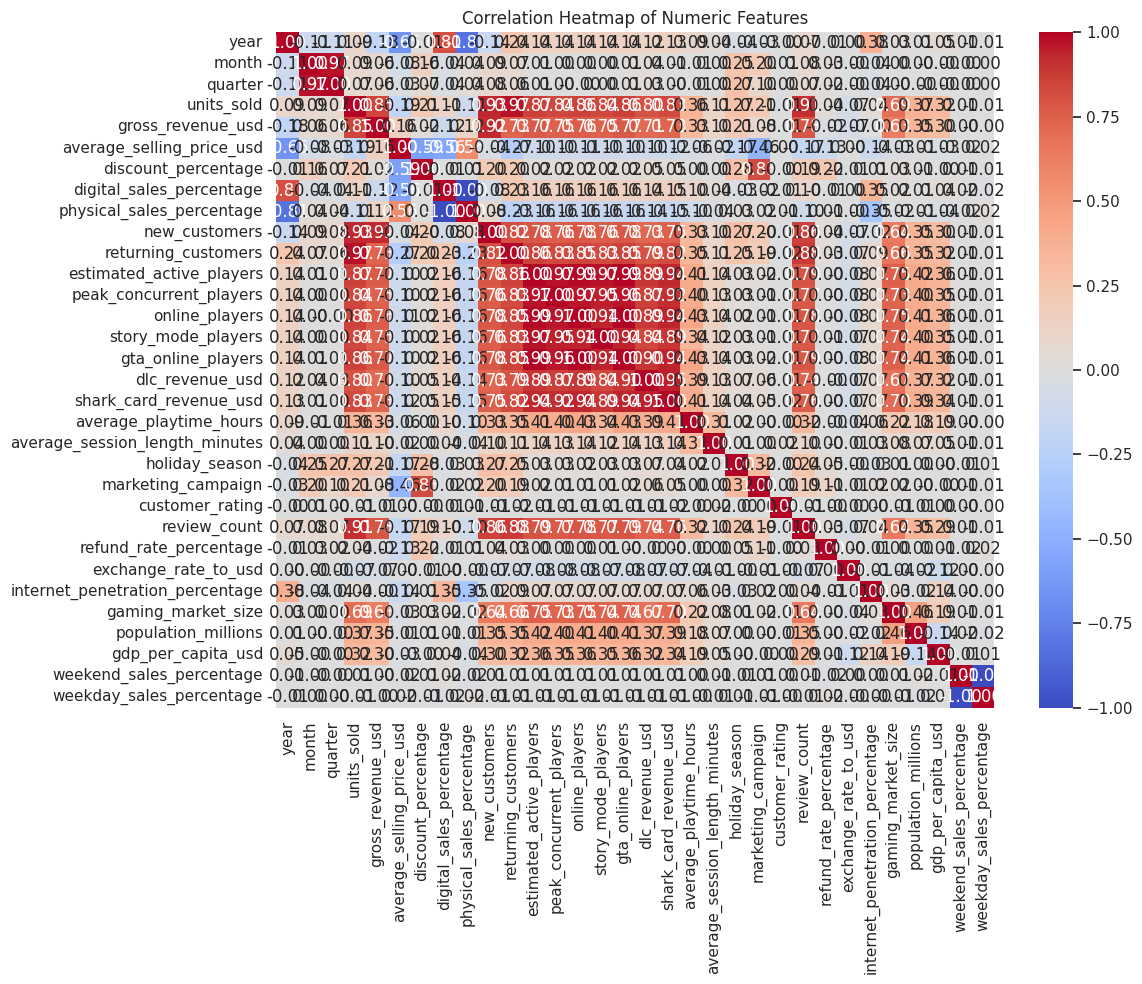

In [15]:
# Extract numeric features
numeric_df = df.select_dtypes(include=[np.number])

# Generate correlation heatmap if there are at least 4 numeric columns
if numeric_df.shape[1] >= 4:
    plt.figure(figsize=(12,10))
    corr = numeric_df.corr()
    sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
    plt.title('Correlation Heatmap of Numeric Features')
    plt.tight_layout()
    plt.show()
else:
    print('Not enough numeric features for correlation heatmap.')


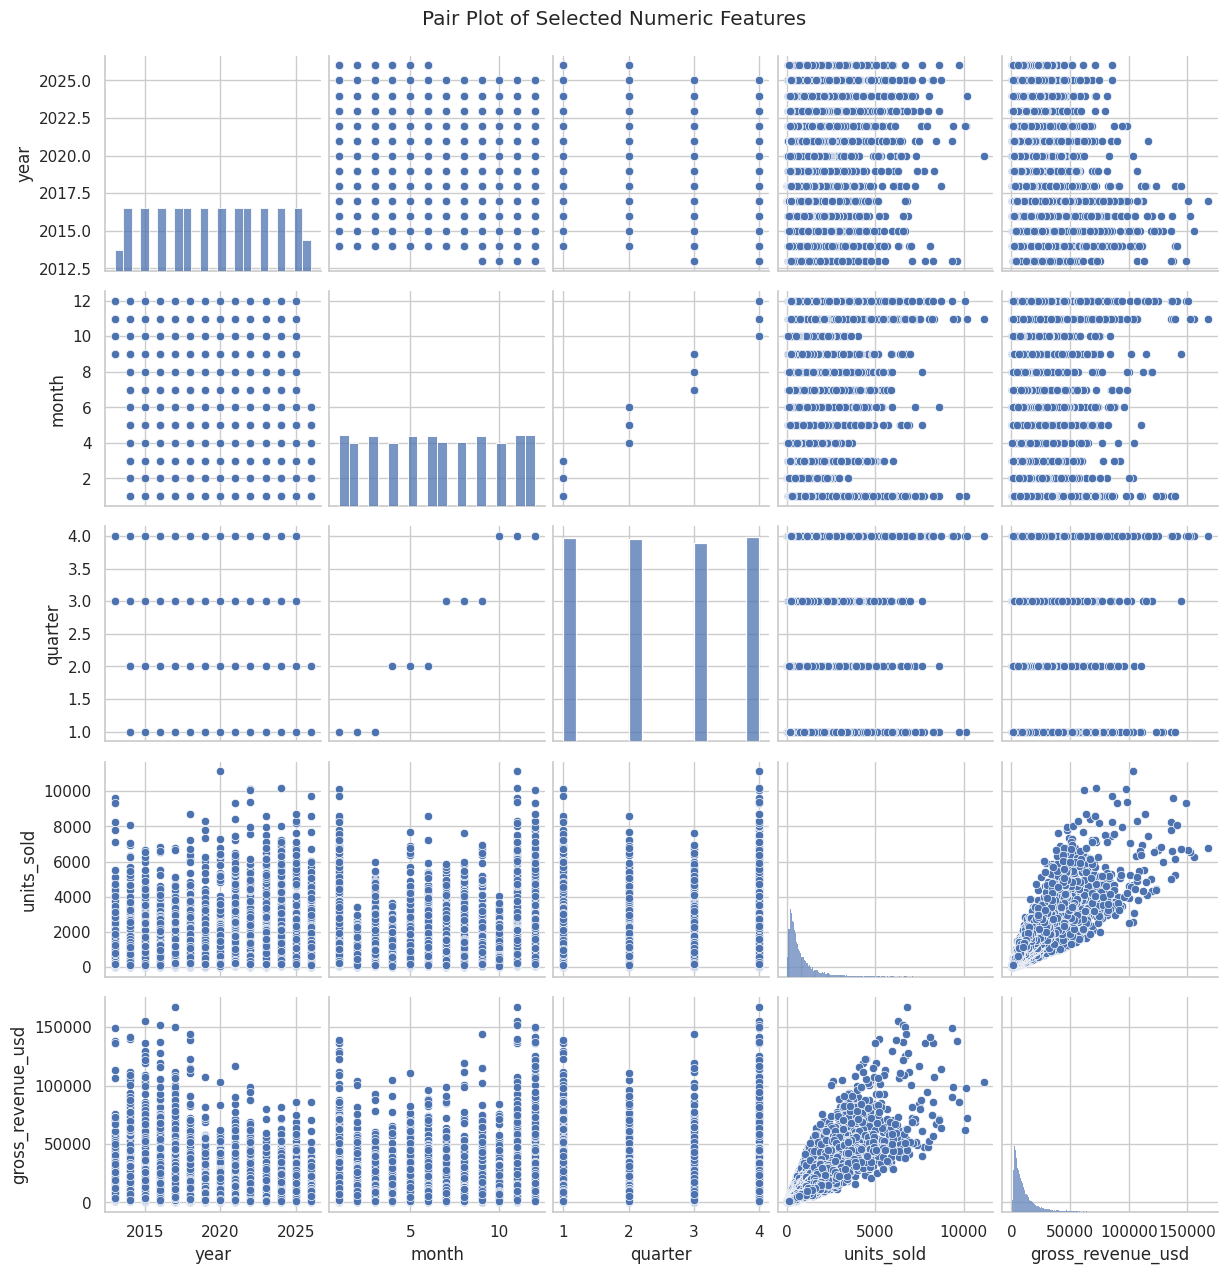

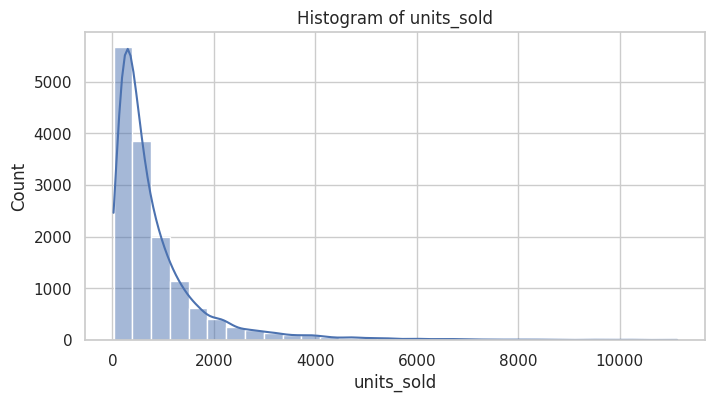

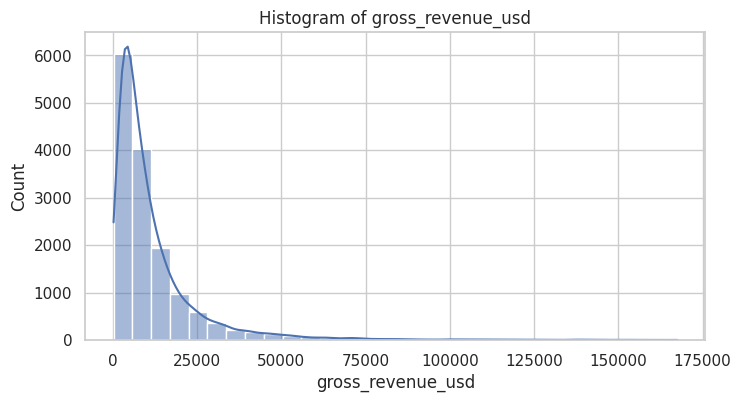

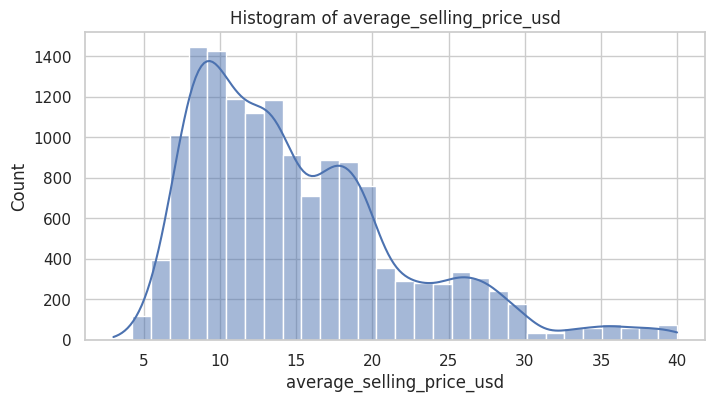

In [16]:
# Pair plot for a subset of numeric features (sample to avoid over-plotting)
selected_cols = numeric_df.columns[:5]  # selecting first 5 numeric columns
sns.pairplot(df[selected_cols])
plt.suptitle('Pair Plot of Selected Numeric Features', y=1.02)
plt.show()

# Histograms for some key numeric features
for col in ['units_sold', 'gross_revenue_usd', 'average_selling_price_usd']:
    if col in df.columns:
        plt.figure(figsize=(8,4))
        sns.histplot(df[col], kde=True, bins=30)
        plt.title(f'Histogram of {col}')
        plt.xlabel(col)
        plt.ylabel('Count')
        plt.show()


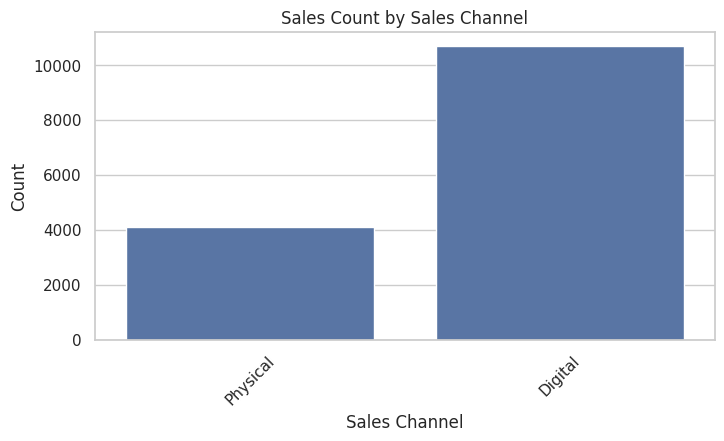

In [17]:
# Count plot (Pie chart style) for categorical variable: sales_channel
if 'sales_channel' in df.columns:
    plt.figure(figsize=(8,4))
    sns.countplot(data=df, x='sales_channel')
    plt.title('Sales Count by Sales Channel')
    plt.xlabel('Sales Channel')
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.show()


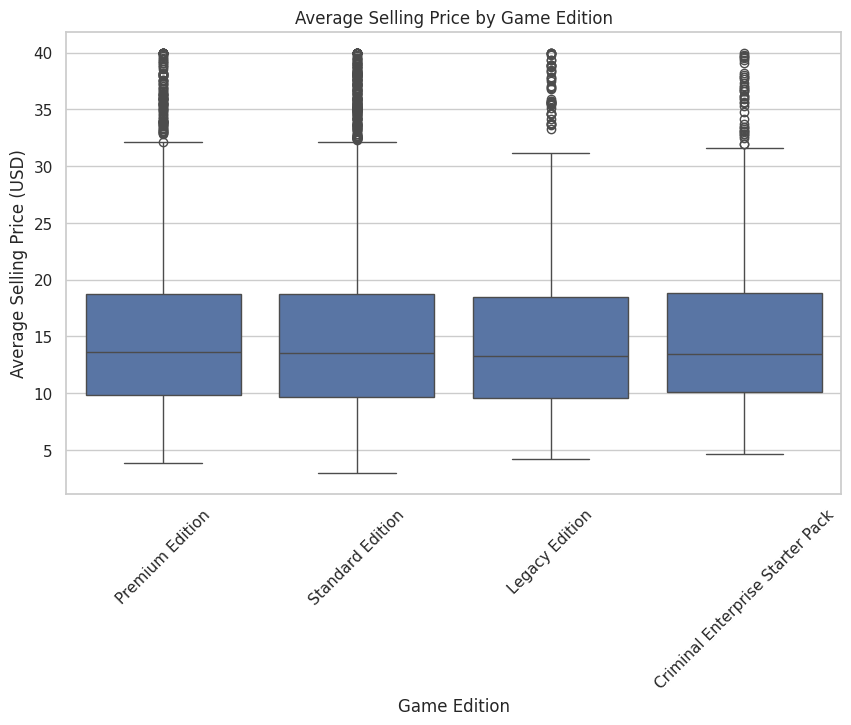

In [18]:
if 'game_edition' in df.columns and 'average_selling_price_usd' in df.columns:
    plt.figure(figsize=(10,6))
    sns.boxplot(data=df, x='game_edition', y='average_selling_price_usd')
    plt.title('Average Selling Price by Game Edition')
    plt.xlabel('Game Edition')
    plt.ylabel('Average Selling Price (USD)')
    plt.xticks(rotation=45)
    plt.show()

## Feature engineering

R2 Score for predicting units_sold: 1.0000


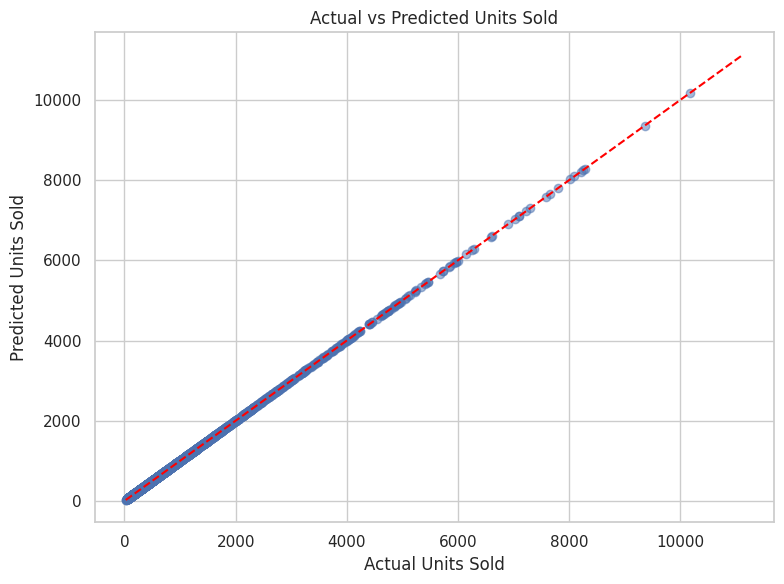

In [19]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split

# Prepare the feature set and target variable
target = 'units_sold'
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

if target in numeric_cols:
    numeric_cols.remove(target)
else:
    raise ValueError(f"Target column '{target}' not found in numeric columns.")

# Fill any remaining missing values (if any)
X = df[numeric_cols].fillna(0)
y = df[target].fillna(0)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# Create and train the regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Generate predictions and calculate the R2 score
y_pred = model.predict(X_test)
score = r2_score(y_test, y_pred)
print(f'R2 Score for predicting {target}: {score:.4f}')

# Optional: Visualize actual vs predicted values
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel('Actual Units Sold')
plt.ylabel('Predicted Units Sold')
plt.title('Actual vs Predicted Units Sold')
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', linestyle='--')
plt.tight_layout()
plt.show()

## Thank you..pls upvote!!!!!!!!!!!